# Full-corpus review readiness: from FIA archive to analyzable evidence

This notebook is the first study-wide report for the 2018–2025 Formula One stewarding corpus. It demonstrates the denominator, review workload, preliminary machine-suggestion patterns, and timing-evidence coverage before human coding. It deliberately does **not** estimate steward error, nationality bias, sanction inconsistency, competitive harm, or fairness: those claims remain gated by final disposition and independent review.

In [1]:
# ruff: noqa: E402
import os
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.jupyter' / 'mplconfig'))

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from f1stewards.coding_workspace import (
    audit_full_corpus_coding_workspace,
    load_timing_review_context,
    write_full_corpus_coding_workspace,
)

DB_PATH = ROOT / 'data' / 'processed' / 'f1_stewarding.duckdb'
SEED_DIRECTORY = ROOT / 'data' / 'manual' / 'full_corpus_seed'
WORKSPACE_ROOT = ROOT / 'data' / 'manual' / 'full_corpus_workspaces'

with duckdb.connect(str(DB_PATH), read_only=True) as connection:
    session_context, driver_context = load_timing_review_context(connection)
workspace_path, workspace_manifest, _ = write_full_corpus_coding_workspace(
    SEED_DIRECTORY, WORKSPACE_ROOT, session_context, driver_context
)
starter_audit = audit_full_corpus_coding_workspace(
    SEED_DIRECTORY, workspace_path, session_context, driver_context
)
documents = pd.read_csv(
    workspace_path / 'document_review_worklist.csv', dtype=str, keep_default_na=False
)
adjudications = pd.read_csv(
    workspace_path / 'adjudication_coding_worklist.csv', dtype=str, keep_default_na=False
)
exclusion_qa = pd.read_csv(
    workspace_path / 'exclusion_qa_worklist.csv', dtype=str, keep_default_na=False
)
for frame in (documents, adjudications, exclusion_qa):
    frame['season'] = pd.to_numeric(frame['season'], errors='raise')
for column in (
    'timing_session_expected',
    'timing_session_loaded',
    'accused_driver_result_present_suggestion',
    'parser_review_required',
):
    adjudications[column] = adjudications[column].str.casefold().eq('true')
for column in (
    'timing_lap_rows',
    'timing_incident_eligible_rows',
    'timing_pace_eligible_rows',
    'timing_beyond_classified_rows',
    'timing_missing_within_rows',
    'timing_fallback_rows',
    'timing_missing_timestamp_rows',
):
    adjudications[column] = pd.to_numeric(adjudications[column], errors='coerce')

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 100)
PRIMARY_COLOR = '#d62728'
SECONDARY_COLOR = '#1f77b4'
NEUTRAL_COLOR = '#6b7280'

## 1. Reproducibility and release gate

The worklists are rebuilt from a protected seed release and content-addressed timing context. Exact hashes must pass before any row is interpreted. Human-review gates remain separate from technical completeness.

In [2]:
primary = adjudications.loc[
    adjudications['eligibility_suggestion'].eq('primary_candidate')
].copy()
secondary = adjudications.loc[
    adjudications['eligibility_suggestion'].eq('secondary_candidate')
].copy()
gate = pd.DataFrame(
    [
        ('Exact workspace hashes', starter_audit['status'].eq('pass').all(), 'technical'),
        ('Expected Race/Sprint timing sessions', len(session_context) == 197, 'technical'),
        ('Primary timing session linked', primary['timing_session_loaded'].all(), 'technical'),
        (
            'Primary accused-driver classification linked',
            primary['accused_driver_result_present_suggestion'].all(),
            'technical',
        ),
        ('Document dispositions reviewed', documents['review_status'].ne('').all(), 'human'),
        ('Adjudications reviewed', adjudications['review_status'].ne('').all(), 'human'),
        ('Exclusion-QA sample reviewed', exclusion_qa['review_status'].ne('').all(), 'human'),
    ],
    columns=['control', 'passed', 'gate_type'],
)
gate['status'] = gate['passed'].map({True: 'PASS', False: 'PENDING'})
identity = pd.DataFrame(
    {
        'release_item': [
            'Workspace ID',
            'Protected seed manifest',
            'Timing context',
            'Workspace content',
        ],
        'value': [
            workspace_manifest['workspace_id'],
            workspace_manifest['protected_seed_manifest_sha256'],
            workspace_manifest['timing_context_sha256'],
            workspace_manifest['workspace_content_sha256'],
        ],
    }
)
display(identity)
display(gate[['gate_type', 'control', 'status']])

,release_item,value
0,Workspace ID,full-coding-02d451b08b7e
1,Protected seed manifest,180b98963a04a626ff89ed933d342b6238c7c5d8d6b979fbec0d838482af5489
2,Timing context,3227b6dac56635caa08a71a9ba789cecc59bb4557786749d9f997d9531e35264
3,Workspace content,8fd7fc4f78f92dc93797176f0665ef69906246e96241f09e6721faec0ab8412a


,gate_type,control,status
0,technical,Exact workspace hashes,PASS
1,technical,Expected Race/Sprint timing sessions,PASS
2,technical,Primary timing session linked,PASS
3,technical,Primary accused-driver classification linked,PASS
4,human,Document dispositions reviewed,PENDING
5,human,Adjudications reviewed,PENDING
6,human,Exclusion-QA sample reviewed,PENDING


## 2. Denominator and proposed attrition

All 2,002 FIA archive outcome labels remain visible. The bars below are machine-generated review destinations—not final inclusion counts. Recalled, corrected, unavailable, and content-mismatched records are retained so missingness cannot quietly become a no-action outcome.

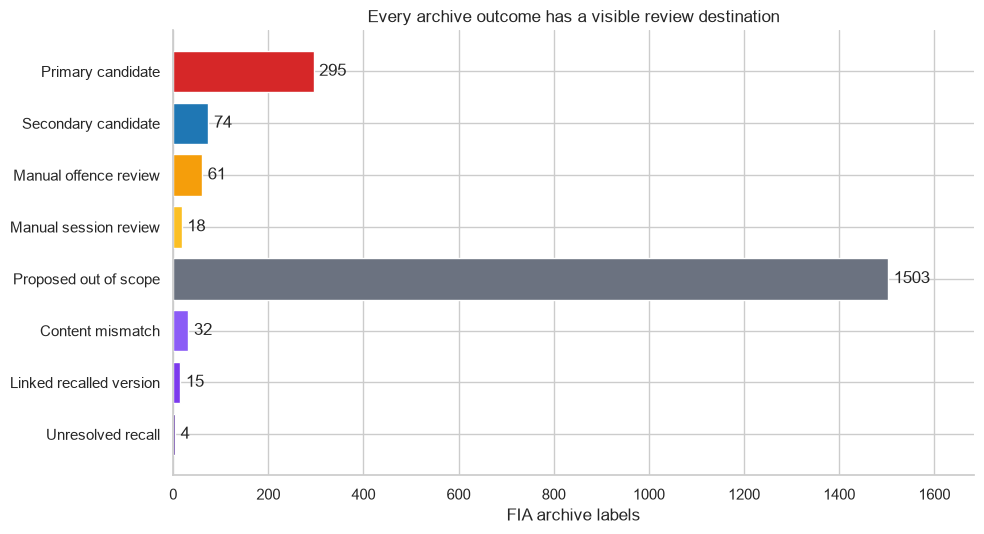

,label,documents
0,Primary candidate,295
1,Secondary candidate,74
2,Manual offence review,61
3,Manual session review,18
4,Proposed out of scope,1503
5,Content mismatch,32
6,Linked recalled version,15
7,Unresolved recall,4


In [3]:
eligibility_order = [
    'primary_candidate',
    'secondary_candidate',
    'manual_offence_review',
    'manual_session_review',
    'out_of_scope_suggestion',
    'content_exclusion_suggestion',
    'version_exclusion_suggestion',
    'version_resolution_required',
]
eligibility_labels = {
    'primary_candidate': 'Primary candidate',
    'secondary_candidate': 'Secondary candidate',
    'manual_offence_review': 'Manual offence review',
    'manual_session_review': 'Manual session review',
    'out_of_scope_suggestion': 'Proposed out of scope',
    'content_exclusion_suggestion': 'Content mismatch',
    'version_exclusion_suggestion': 'Linked recalled version',
    'version_resolution_required': 'Unresolved recall',
}
eligibility_counts = (
    documents['eligibility_suggestion']
    .value_counts()
    .reindex(eligibility_order, fill_value=0)
    .rename_axis('eligibility_suggestion')
    .reset_index(name='documents')
)
eligibility_counts['label'] = eligibility_counts['eligibility_suggestion'].map(
    eligibility_labels
)
colors = [
    PRIMARY_COLOR,
    SECONDARY_COLOR,
    '#f59e0b',
    '#fbbf24',
    NEUTRAL_COLOR,
    '#8b5cf6',
    '#7c3aed',
    '#4c1d95',
]
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(eligibility_counts['label'], eligibility_counts['documents'], color=colors)
ax.bar_label(bars, padding=4, fmt='%.0f')
ax.invert_yaxis()
ax.set(
    title='Every archive outcome has a visible review destination',
    xlabel='FIA archive labels',
    ylabel='',
)
ax.set_xlim(0, eligibility_counts['documents'].max() * 1.12)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()
display(eligibility_counts[['label', 'documents']])

## 3. Review workload across seasons

A season-level view exposes documentation-era differences and prevents the recent, more standardized archive from dominating the review plan. Changes over time may reflect publication and parsing conditions as well as real stewarding activity.

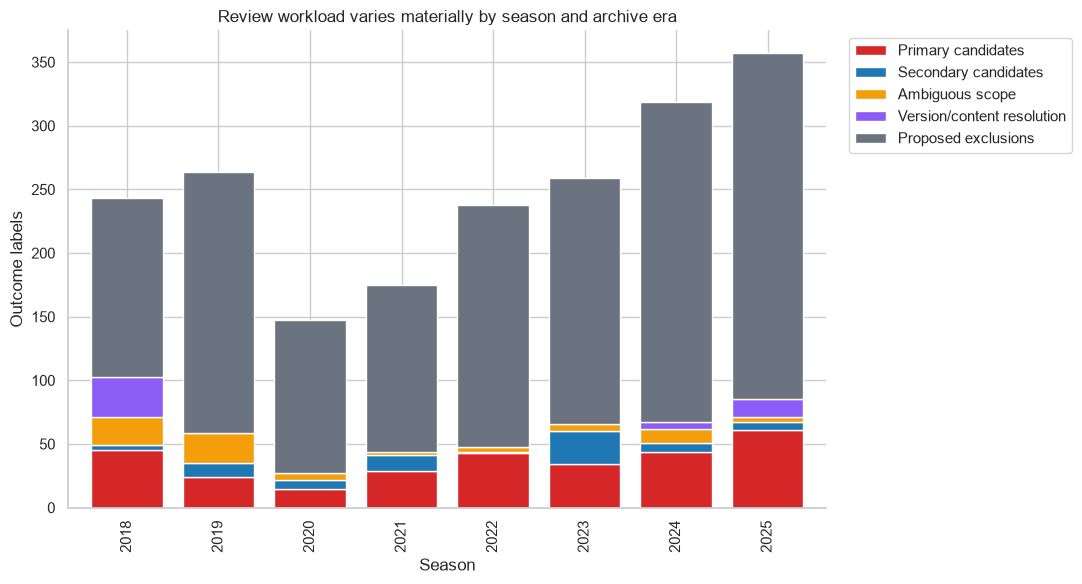

review_workstream,Primary candidates,Secondary candidates,Ambiguous scope,Version/content resolution,Proposed exclusions,total
season,,,,,,
2018,45,4,22,32,140,243
2019,24,11,24,0,205,264
2020,15,7,5,0,120,147
2021,29,12,3,0,131,175
2022,43,1,4,0,190,238
2023,34,26,6,0,193,259
2024,44,7,11,5,252,319
2025,61,6,4,14,272,357


In [4]:
workstream_map = {
    'primary_candidate': 'Primary candidates',
    'primary_parser_review': 'Primary candidates',
    'secondary_candidate': 'Secondary candidates',
    'secondary_parser_review': 'Secondary candidates',
    'manual_scope_review': 'Ambiguous scope',
    'proposed_exclusion': 'Proposed exclusions',
    'version_or_content': 'Version/content resolution',
    'version_resolution': 'Version/content resolution',
}
documents['review_workstream'] = documents['workspace_priority_bucket'].map(workstream_map)
workstream_order = [
    'Primary candidates',
    'Secondary candidates',
    'Ambiguous scope',
    'Version/content resolution',
    'Proposed exclusions',
]
season_workload = (
    documents.groupby(['season', 'review_workstream']).size().unstack(fill_value=0)
    .reindex(columns=workstream_order, fill_value=0)
)
ax = season_workload.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 6),
    color=[PRIMARY_COLOR, SECONDARY_COLOR, '#f59e0b', '#8b5cf6', NEUTRAL_COLOR],
    width=0.78,
)
ax.set(
    title='Review workload varies materially by season and archive era',
    xlabel='Season',
    ylabel='Outcome labels',
)
ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()
display(season_workload.assign(total=season_workload.sum(axis=1)))

## 4. SQL profile of primary machine candidates

DuckDB keeps the analytical transformation explicit. The query below profiles candidate documents only; it does not assert that an allegation was proven or that a sanction was correct. No-action decisions remain observable outcomes rather than missing values.

In [5]:
sql = '''
SELECT
    offence_family_suggestion AS incident_family,
    outcome_family_suggestion AS outcome_family,
    count(*) AS candidate_documents,
    count(DISTINCT event_id) AS represented_events
FROM adjudication_worklist
WHERE eligibility_suggestion = 'primary_candidate'
GROUP BY 1, 2
ORDER BY candidate_documents DESC, incident_family, outcome_family
'''
with duckdb.connect() as analytical_sql:
    analytical_sql.register('adjudication_worklist', adjudications)
    primary_profile = analytical_sql.sql(sql).df()
display(Markdown('```sql\n' + sql.strip() + '\n```'))
display(primary_profile)

```sql
SELECT
    offence_family_suggestion AS incident_family,
    outcome_family_suggestion AS outcome_family,
    count(*) AS candidate_documents,
    count(DISTINCT event_id) AS represented_events
FROM adjudication_worklist
WHERE eligibility_suggestion = 'primary_candidate'
GROUP BY 1, 2
ORDER BY candidate_documents DESC, incident_family, outcome_family
```

,incident_family,outcome_family,candidate_documents,represented_events
0,causing_collision,time_penalty,97,68
1,causing_collision,no_further_action,58,32
2,gaining_advantage_off_track,time_penalty,36,25
3,forcing_off_track,time_penalty,20,16
4,causing_collision,grid_penalty,19,16
5,forcing_off_track,no_further_action,16,13
6,gaining_advantage_off_track,no_further_action,13,11
7,causing_collision,other,8,7
8,causing_collision,reprimand,5,3
9,multiple_defensive_moves,time_penalty,5,3


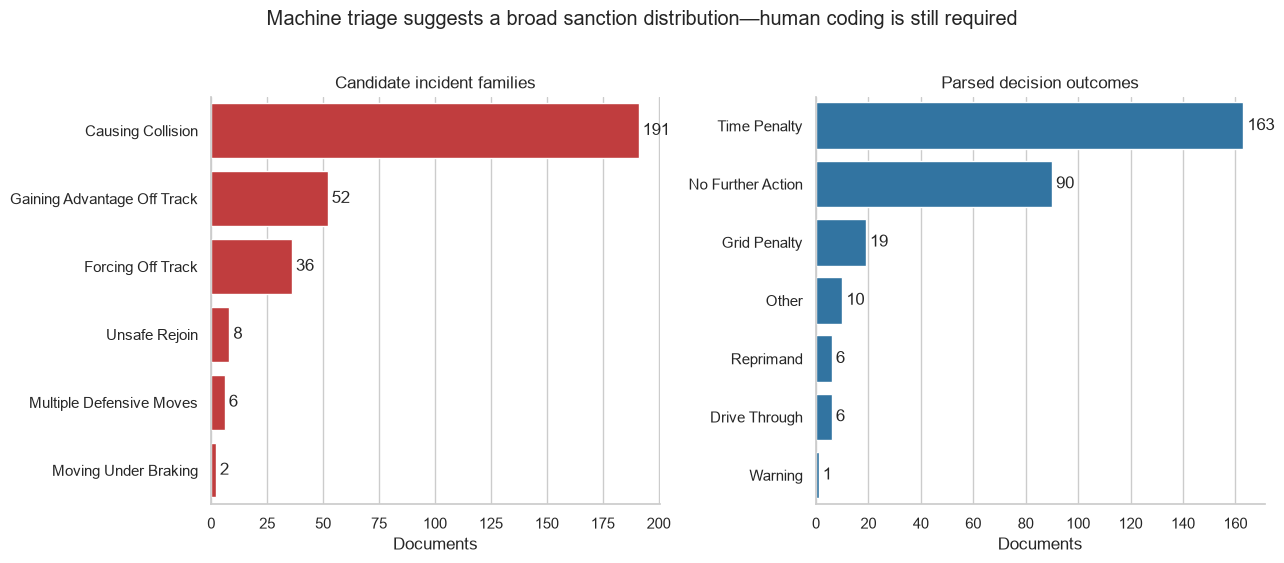

In [6]:
primary['incident_family_label'] = (
    primary['offence_family_suggestion'].str.replace('_', ' ').str.title()
)
primary['outcome_family_label'] = (
    primary['outcome_family_suggestion'].str.replace('_', ' ').str.title()
)
family_order = primary['incident_family_label'].value_counts().index
outcome_order = primary['outcome_family_label'].value_counts().index
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.countplot(
    data=primary,
    y='incident_family_label',
    order=family_order,
    color=PRIMARY_COLOR,
    ax=axes[0],
)
axes[0].set(title='Candidate incident families', xlabel='Documents', ylabel='')
sns.countplot(
    data=primary,
    y='outcome_family_label',
    order=outcome_order,
    color=SECONDARY_COLOR,
    ax=axes[1],
)
axes[1].set(title='Parsed decision outcomes', xlabel='Documents', ylabel='')
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, padding=3)
    sns.despine(ax=ax)
plt.suptitle(
    'Machine triage suggests a broad sanction distribution—human coding is still required',
    y=1.02,
)
plt.tight_layout()
plt.show()

## 5. Timing evidence and known limitations

Timing is joined at two levels: session quality for chronology and pace-model eligibility, and accused-driver classification coverage. Session counts are deduplicated below so events with several decisions do not inflate coverage.

In [7]:
primary_sessions = primary.drop_duplicates(['event_id', 'session_type_suggestion']).copy()
timing_summary = pd.DataFrame(
    [
        ('Primary candidate documents', len(primary), 'document'),
        ('Represented Race/Sprint sessions', len(primary_sessions), 'session'),
        (
            'Loaded represented sessions',
            int(primary_sessions['timing_session_loaded'].sum()),
            'session',
        ),
        (
            'Primary documents with accused-driver result',
            int(primary['accused_driver_result_present_suggestion'].sum()),
            'document',
        ),
        (
            'Represented sessions with unavailable absolute timestamps',
            int(primary_sessions['timing_missing_timestamp_rows'].fillna(0).gt(0).sum()),
            'session',
        ),
        (
            'Represented sessions missing within-distance timing rows',
            int(primary_sessions['timing_missing_within_rows'].fillna(0).gt(0).sum()),
            'session',
        ),
        (
            'Represented sessions using raw timing fallback',
            int(primary_sessions['timing_fallback_rows'].fillna(0).gt(0).sum()),
            'session',
        ),
    ],
    columns=['measure', 'count', 'unit'],
)
quality_register = pd.DataFrame(
    [
        (
            '2018-bhr',
            'One within-classified-distance timing row is unavailable.',
            'Do not impute; inspect FIA/FastF1 evidence for affected incident reconstruction.',
        ),
        (
            '2022-fra',
            'All 958 laps are relative-only; no trustworthy absolute session anchor exists.',
            'Use lap-relative evidence only; do not substitute the scheduled start time.',
        ),
        (
            '2018-ita',
            'Processed laps failed and 925 raw timing rows were retained.',
            (
                'Available for incident timing, excluded from strict pace models; '
                'no primary candidate uses it.'
            ),
        ),
    ],
    columns=['event_id', 'source limitation', 'analytical treatment'],
)
display(timing_summary)
display(quality_register)

,measure,count,unit
0,Primary candidate documents,295,document
1,Represented Race/Sprint sessions,137,session
2,Loaded represented sessions,137,session
3,Primary documents with accused-driver result,295,document
4,Represented sessions with unavailable absolute timestamps,1,session
5,Represented sessions missing within-distance timing rows,2,session
6,Represented sessions using raw timing fallback,1,session


,event_id,source limitation,analytical treatment
0,2018-bhr,One within-classified-distance timing row is unavailable.,Do not impute; inspect FIA/FastF1 evidence for affected incident reconstruction.
1,2022-fra,All 958 laps are relative-only; no trustworthy absolute session anchor exists.,Use lap-relative evidence only; do not substitute the scheduled start time.
2,2018-ita,Processed laps failed and 925 raw timing rows were retained.,"Available for incident timing, excluded from strict pace models; no primary candidate uses it."


## 6. Readiness conclusion

Technical collection is complete, but analytical readiness is intentionally blocked. This distinction is the central control: a complete database does not make unreviewed classifications fit for inference.

In [8]:
pending_human = gate.loc[
    gate['gate_type'].eq('human') & ~gate['passed'], 'control'
].tolist()
no_action_count = int(
    primary['outcome_family_suggestion'].eq('no_further_action').sum()
)
denominator_line = (
    f"- The official-evidence denominator is preserved: **{len(documents):,}** "
    f"outcome labels, **{len(adjudications):,}** live decision starters, and "
    f"**{len(exclusion_qa):,}** stratified exclusion checks."
)
coverage_line = (
    f"- Technical coverage is strong: all **{len(primary):,}** primary candidates "
    "join to a loaded Race/Sprint session and accused-driver classification."
)
candidate_line = (
    f"- The preliminary candidate mix—including **{no_action_count:,}** "
    "no-further-action documents—is a review workload, not an error or leniency estimate."
)
next_line = (
    "- Next: code final eligibility and accused-driver units, audit exclusions, "
    "independently review incident grouping/outcomes, then construct harm and "
    "sanction-impact records before fitting consistency or nationality models."
)
conclusion = '\n'.join(
    [
        '### Decision: `BLOCKED_PENDING_HUMAN_REVIEW`',
        '',
        denominator_line,
        coverage_line,
        candidate_line,
        f"- Remaining publication gates: **{'; '.join(pending_human)}**.",
        next_line,
        '',
        (
            'This is the defensible handoff from data engineering and EDA to '
            'controlled analytical coding.'
        ),
    ]
)
display(Markdown(conclusion))

### Decision: `BLOCKED_PENDING_HUMAN_REVIEW`

- The official-evidence denominator is preserved: **2,002** outcome labels, **1,951** live decision starters, and **485** stratified exclusion checks.
- Technical coverage is strong: all **295** primary candidates join to a loaded Race/Sprint session and accused-driver classification.
- The preliminary candidate mix—including **90** no-further-action documents—is a review workload, not an error or leniency estimate.
- Remaining publication gates: **Document dispositions reviewed; Adjudications reviewed; Exclusion-QA sample reviewed**.
- Next: code final eligibility and accused-driver units, audit exclusions, independently review incident grouping/outcomes, then construct harm and sanction-impact records before fitting consistency or nationality models.

This is the defensible handoff from data engineering and EDA to controlled analytical coding.